In [2]:
# pyright: reportUnusedImport=false, reportMissingImports=false, reportMissingModuleSource=false
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import seaborn as sb
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Rescaling
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split



I0000 00:00:1777901227.697724   70027 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
normal_cells=os.listdir('brain_tumor_dataset/no/')
tumor_cells=os.listdir('brain_tumor_dataset/yes/')

# total images in each folder

In [4]:
print('Number of normal cells: ',len(normal_cells))
print('Number of tumor cells: ',len(tumor_cells))

Number of normal cells:  98
Number of tumor cells:  155


In [5]:
TRAIN_DIR='brain_tumor_dataset'

# image resize 

In [6]:
# Instantiate the dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    seed=100
)

# Check the type    
dataset_type = type(train_dataset)
print(f'train_dataset inherits from tf.data.Dataset: {issubclass(dataset_type, tf.data.Dataset)}')

Found 253 files belonging to 2 classes.


train_dataset inherits from tf.data.Dataset: True


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    seed=100
)
dataset_type = type(train_dataset)
print(f'train_dataset inherits from tf.data.Dataset: {issubclass(dataset_type, tf.data.Dataset)}')

Found 253 files belonging to 2 classes.
Using 50 files for validation.
train_dataset inherits from tf.data.Dataset: True


# validating the image shapes

In [8]:
# check the image shape and labels
for images, labels in train_dataset.take(1):
    print(f'Image batch shape: {images.shape}')
    print(f'Label batch shape: {labels.shape}')

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 1)


In [9]:
# genrate augmented images
data_augumentation=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    vertical_flip=True,
    horizontal_flip=True
)

In [10]:
rescale=Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# improving performance

In [11]:
train_dataset=(
    train_dataset.cache()
    .shuffle(100).
    prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [12]:
val_ds=(
    val_ds.cache()
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# defining early stop at 82 percent

In [13]:
class EarlyStopping(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epoch,logs=None):
        if logs.get("accuracy")>0.82:
            print("\nReached 82% accuracy so cancelling training!")
            self.model.stop_training=True

In [14]:
model=Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),
    Conv2D(16,3,activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32,3,activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64,3,activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,3,activation='relu'),
    MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    Dense(256,activation='relu'),
    Dense(1,activation='sigmoid')


])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,601 (4.87 MB)

 Trainable params: 1,277,601 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# using pre-build early stopping
using validation set also for fitting

In [17]:
history = model.fit(
    train_dataset,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',  
            patience=5,
            restore_best_weights=True
        )
    ]
    )

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - accuracy: 0.5850 - loss: 0.6851 - val_accuracy: 0.7200 - val_loss: 0.6162
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.7194 - loss: 0.5634 - val_accuracy: 0.8000 - val_loss: 0.4414
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.7589 - loss: 0.5955 - val_accuracy: 0.7800 - val_loss: 0.5202
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.7549 - loss: 0.5366 - val_accuracy: 0.8000 - val_loss: 0.4568
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - accuracy: 0.7866 - loss: 0.4883 - val_accuracy: 0.8600 - val_loss: 0.3673
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.8182 - loss: 0.4456 - val_accuracy: 0.8600 - val_loss: 0.3289
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.8103 - loss: 0.4165 - val_accuracy: 0.8800 - val_loss: 0.3281
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.8340 - loss: 0.3705 - val_accuracy: 0.8800 - val_loss:

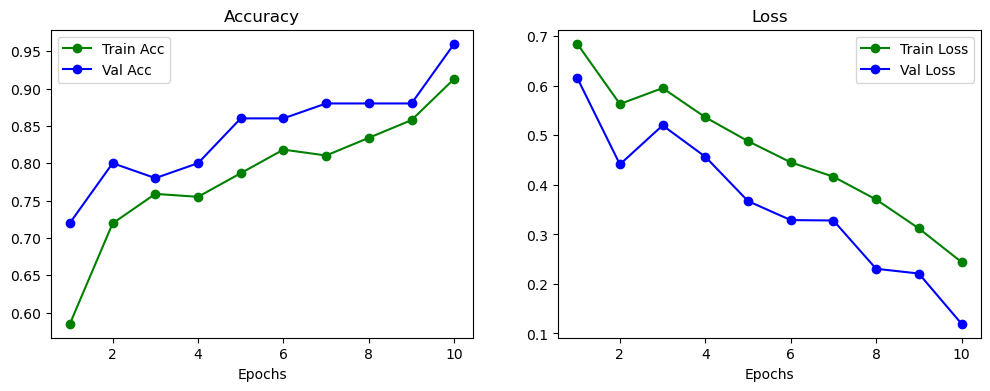

In [18]:

import matplotlib.pyplot as plt
try:
    h = history.history if hasattr(history, 'history') else history
    epochs = range(1, len(next(iter(h.values()))) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    if 'accuracy' in h or 'acc' in h:
        acc = h.get('accuracy') or h.get('acc')
        plt.plot(epochs, acc, 'go-', label='Train Acc')
    if 'val_accuracy' in h or 'val_acc' in h:
        val_acc = h.get('val_accuracy') or h.get('val_acc')
        plt.plot(epochs, val_acc, 'bo-', label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    plt.subplot(1,2,2)
    if 'loss' in h:
        plt.plot(epochs, h['loss'], 'go-', label='Train Loss')
    if 'val_loss' in h:
        plt.plot(epochs, h['val_loss'], 'bo-', label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()
except Exception as e:
    print('Plot failed:', e)
    print('Ensure `history` is the return value from `model.fit(...)`')

In [19]:
Test_Dir="test_images"

In [20]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    Test_Dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    seed=100
)

Found 253 files belonging to 2 classes.


In [21]:
model.evaluate(test_dataset)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9130 - loss: 22.3663


[22.366268157958984, 0.9130434989929199]

In [22]:
model.predict(test_dataset)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step


array([[1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [0.0000000e+00],
       [9.9916726e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.000000

# upload images 

In [23]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image


uploader = widgets.FileUpload(
    accept='image/*',   # Accept all image types
    multiple=False,     # Single file upload
    description='Upload Image',
    button_style='info' # Blue color
)
output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()
        
        
        if not uploader.value:
            print(" Please upload an image first.")
            return
            
        print("🔄 Processing...")
        
        
        # Support both dict (new ipywidgets) and list/tuple formats
        if isinstance(uploader.value, dict):
            uploaded_file = next(iter(uploader.value.values()))
        else:
            uploaded_file = uploader.value[0]

        # filename may be at top-level or under metadata depending on widget/version
        filename = uploaded_file.get('name') or (uploaded_file.get('metadata') or {}).get('name', 'uploaded_image')
        content = uploaded_file.get('content') or uploaded_file.get('data')
        
        
        image = Image.open(io.BytesIO(content)).convert('RGB')
        display_img = image.copy()
        display_img.thumbnail((200, 200)) 
        
        
        image = image.resize((128, 128))
        image_array = np.array(image) / 255.0
        image_array = np.expand_dims(image_array, axis=0)

        
        prediction = model.predict(image_array, verbose=0)[0][0]
        label = 'Tumor' if prediction >= 0.5 else 'Normal'
        confidence = prediction if prediction >= 0.5 else 1 - prediction

        
        display(display_img)
        print(f'📄 File: {filename}')
        print(f'✅ Prediction: {label}')
        print(f'📊 Confidence: {confidence:.2%}')


predict_btn = widgets.Button(
    description='Predict Tumor',
    button_style='success', 
    tooltip='Click to analyze the uploaded image'
)
predict_btn.on_click(on_predict_clicked)


print("--- Brain Tumor Classifier ---")
display(widgets.VBox([uploader, predict_btn, output]))


--- Brain Tumor Classifier ---


### wraping our model in .keras(.h5) to consume at backend fast api

In [24]:
model.save('brain_tumor_classifier.keras')